<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/1.2-fourier-transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Fourier transform and the spectrogram

**Joseph Fourier** was a French mathematician who, around 1807, proposed that any periodic function—that is, any signal that repeats over time—can be represented as a sum of sinusoidal functions with different frequencies, amplitudes, and phases. He developed what we now know as the Fourier transform, giving the world a tool as fascinating as it is fundamental for signal analysis and processing.

Today, this is the basis of spectral analysis, which allows a signal to be precisely decomposed into its frequency components from magnitude and phase coefficients; these provide information about the intensity and phase shift of each sinusoidal component, respectively. In this way, and thanks to technological advances, it is possible to manipulate, analyze, and process signals digitally, which has enabled a wide range of applications in fields such as engineering, telecommunications, and medicine.

In this notebook we will limit ourselves to processing the two audio files used previously, with the goal of visualizing and analyzing these signals through the Fourier transform and the spectrogram. To do so, we will use **Librosa**, a Python library that is widely used in the signal-processing and machine-learning community, and which provides a broad range of functions to load, analyze, and process this type of data.

If you want to dive deeper into the Fourier transform, start with the following audiovisual content from the YouTube channel **3Blue1Brown**, which explains its fundamental concepts in an interactive and clear way:

[![Video of 3Blue1Brown about the Fourier transform](https://img.youtube.com/vi/spUNpyF58BY/0.jpg)](https://www.youtube.com/watch?v=spUNpyF58BY)

As for reading material, **Fundamentals of Music Processing** by Meinard Müller is a very complete book that includes practical examples in Python notebooks. It covers all the fundamentals of audio signal processing, including, of course, the Fourier transform. The book is available online: [Fundamentals of Music Processing](https://link.springer.com/book/10.1007/978-3-030-69808-9)

In [1]:
# Imports
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os
import IPython.display as ipd

In [2]:
# Playback of the clips
BASE_DIR = "/content/Actor_01"
audio_file_1 = os.path.join(BASE_DIR, "01.wav")
audio_file_2 = os.path.join(BASE_DIR, "05.wav")

In [3]:
# Playing the files
ipd.Audio(audio_file_1)

In [4]:
ipd.Audio(audio_file_2)

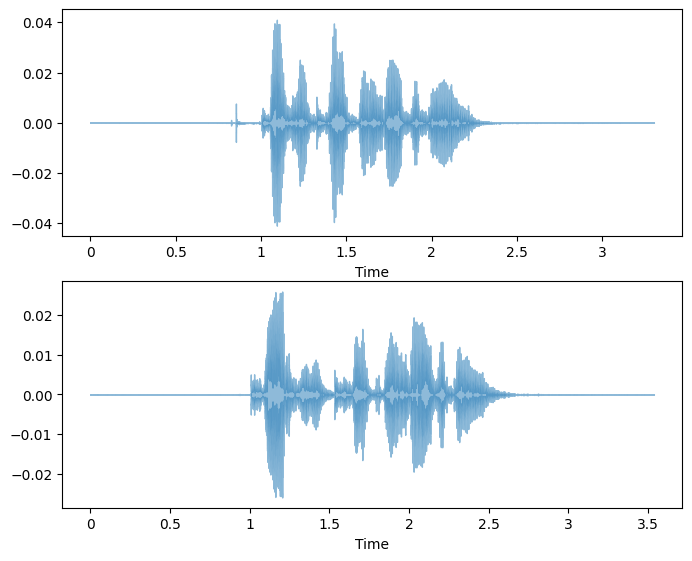

In [9]:
# Load the audio files into a variable
plt.figure(figsize=(8, 10))
ax = plt.subplot(3, 1, 1)
signal, sr = librosa.load(audio_file_1)
signal_2, sr = librosa.load(audio_file_2)

# Plot waveform
librosa.display.waveshow(signal, sr=sr, alpha=0.5)
plt.subplot(3, 1, 2)
librosa.display.waveshow(signal_2, sr=sr, alpha=0.5)
plt.show()

In [7]:
# Apply the Fourier transform to each signal

ft = sp.fft.fft(signal)
ft_2 = sp.fft.fft(signal_2)

magnitude_1 = np.absolute(ft)
frequency_1 = np.linspace(0, sr, len(magnitude_1))

magnitude_2 = np.absolute(ft_2)
frequency_2 = np.linspace(0, sr, len(magnitude_2))

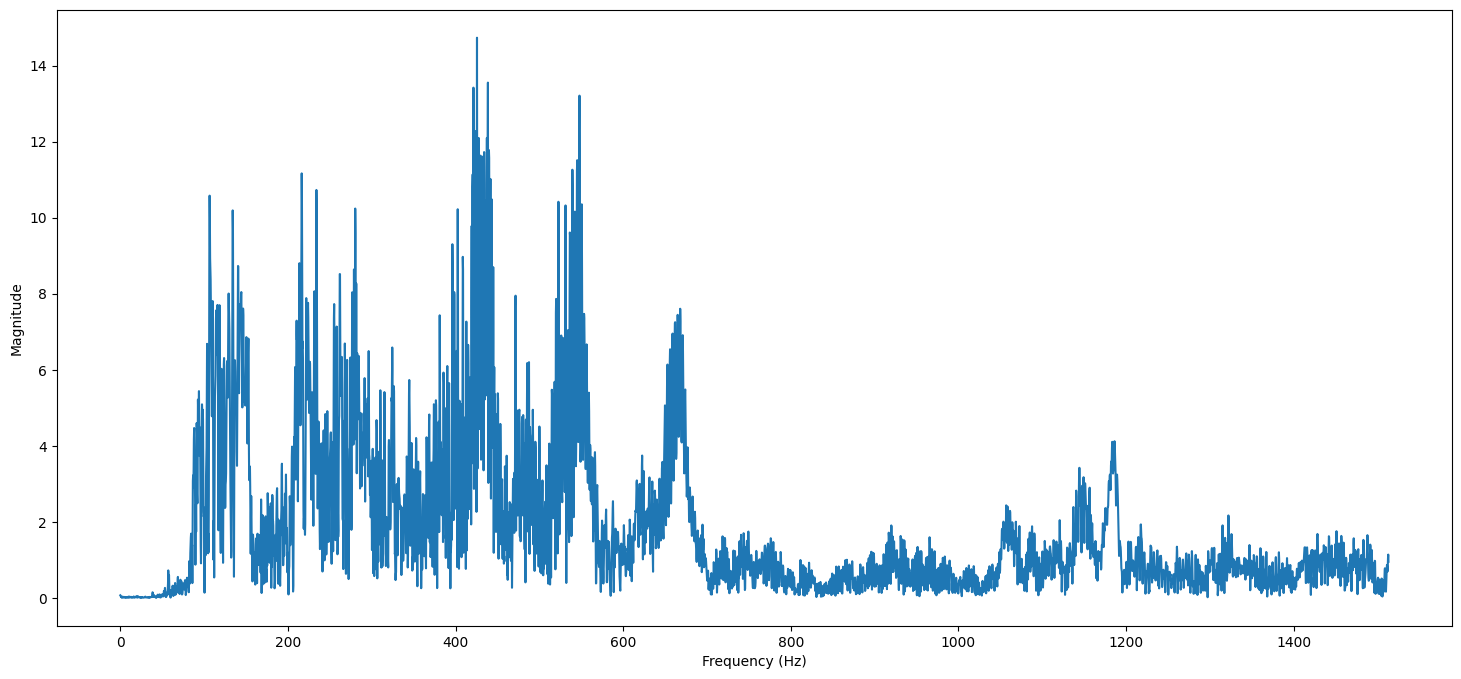

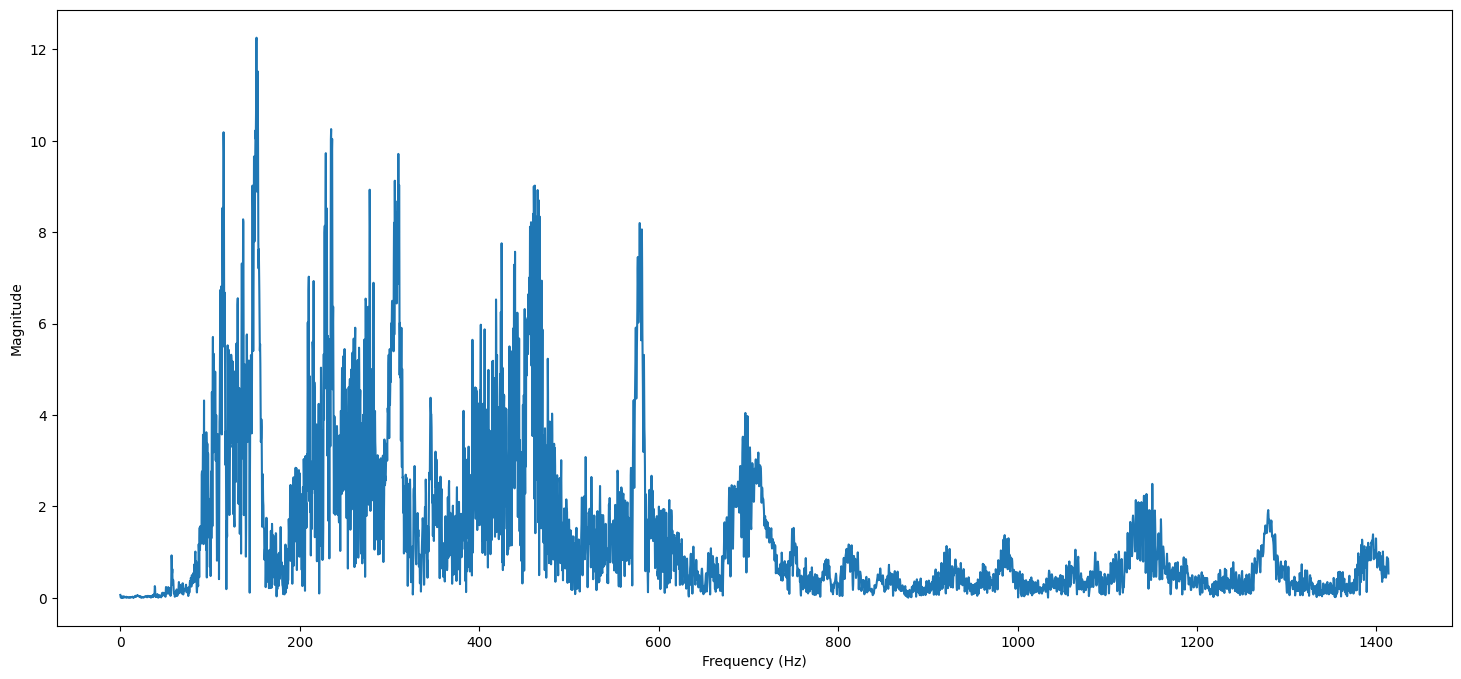

In [8]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency_1[:5000], magnitude_1[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency_2[:5000], magnitude_2[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

As observed in the previous sections, after applying the Fourier transform to the audio clips to obtain a preliminary view of their frequency behavior, it is clear that these representations contain a dense amount of information that is difficult to interpret at a glance. In order to extract enough features to draw conclusions that allow us to differentiate or classify these files, it is necessary to use additional tools. These will let us achieve a simpler, more robust abstraction aligned with how the human auditory system perceives sound; that abstraction will also serve as the basis for training our machine-learning model.

### STFT (Short-Time Fourier Transform)

It is a technique that lets us analyze the temporal evolution of the frequencies present in an audio signal. Unlike the traditional Fourier transform, which provides information about the frequencies contained in a signal but not about the exact instant at which they occur, the STFT divides the signal into smaller segments (windows) and applies the Fourier transform to each one. This makes it possible to obtain a spectrogram, which is a visual representation of how frequencies change over time.

### Mel spectrogram and the logarithmic scale

Because humans can perceive sound intensities across a very wide range, it is common to use a logarithmic scale to represent magnitude in a spectrogram. For example, in terms of acoustic power in watts (W), the human hearing range spans from approximately **$10^{-12}$ W** (threshold of hearing) to **1 W** (threshold of pain). Expressing this linearly yields an unbalanced plot because the magnitude differences are disproportionate. In contrast, using decibels (dB) places the hearing range between **0 dB and 120 dB**. This logarithmic scale is much more intuitive and is best suited to spectrograms because it more precisely displays variations in perceived loudness within the audible range.

The Mel spectrogram is a visual representation of the energy of the frequencies present in an audio signal over time, using the Mel scale for the frequency axis. This is a perceptual scale based on **how humans perceive sound**; it is non-linear because the human ear is very sensitive to changes at low frequencies but has difficulty distinguishing equally spaced changes at high frequencies.

*Example:* For us, the perceptual difference between 500 Hz and 1000 Hz is very noticeable, but between 15,000 Hz and 15,500 Hz it is almost imperceptible.

That is why Mel filters use a bank of triangular filters that become wider as frequency increases.

![Mel filters](https://image2.slideserve.com/4267776/construcci-n-de-los-filtros1-l.jpg)

This makes the Mel spectrogram especially useful for tasks related to audio processing, such as speech recognition and emotion classification, because it aligns well with how the human auditory system processes sound.

In [15]:
# Calculating the spectrogram of each signal

''' First we extract the STFT of each signal'''

FRAME_SIZE = 2048
HOP_SIZE = 512

S_scale_1 = librosa.stft(signal, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)
S_scale_2 = librosa.stft(signal_2, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)

# Observing the nature of our STFT
print(S_scale_1.shape, "Type is: ", S_scale_1.dtype)
print(S_scale_2.shape, "Type is: ", S_scale_2.dtype)

(1025, 143) Type is:  complex64
(1025, 153) Type is:  complex64


Most visualization libraries, including matplotlib (which is behind librosa), are designed to work with real numbers (floats or integers). When given a complex number ($a + bi$), the function does not know what to plot:

* Plot the real part $a$?
* Plot the imaginary part $b$?
* Plot the magnitude?

In [16]:
Y_scale_1 = np.abs(S_scale_1) ** 2
Y_scale_2 = np.abs(S_scale_2) ** 2
print("Type is:" ,Y_scale_1.dtype)

Type is: float32


In [17]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25, 10))
    librosa.display.specshow(Y,
                             sr=sr,
                             hop_length=hop_length,
                             x_axis="time",
                             y_axis=y_axis)
    plt.colorbar(format="%+2.f")

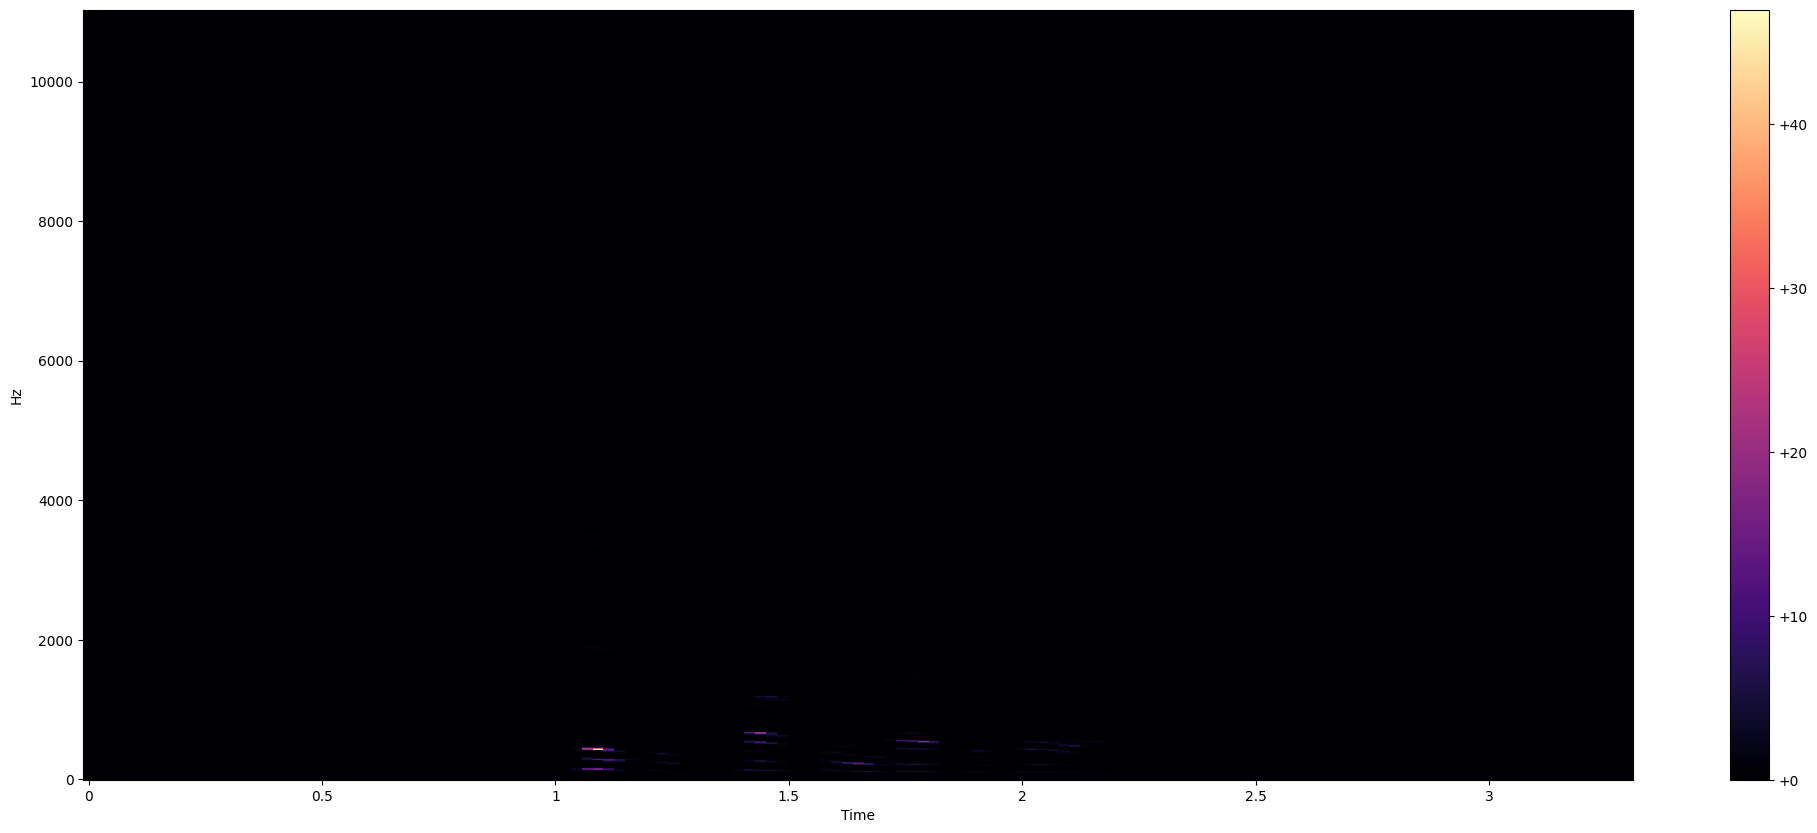

In [18]:
plot_spectrogram(Y_scale_1, sr, HOP_SIZE)

Reminder: The time for each column of the spectrogram is calculated using the following formula:



$$T(m) =
rac{m \cdot 	ext{hop\_length}}{	ext{sr}}$$


Where:$m$: The index of the column (starting at 0).

$	ext{hop\_length}$: The number of audio samples you advance between each STFT window.

$	ext{sr}$: The sampling rate (samples per second), for example, 22050 or 44100 Hz.

This is what happens if we do not apply a logarithmic scale to the magnitude of the STFT, which makes the spectrogram difficult to interpret.

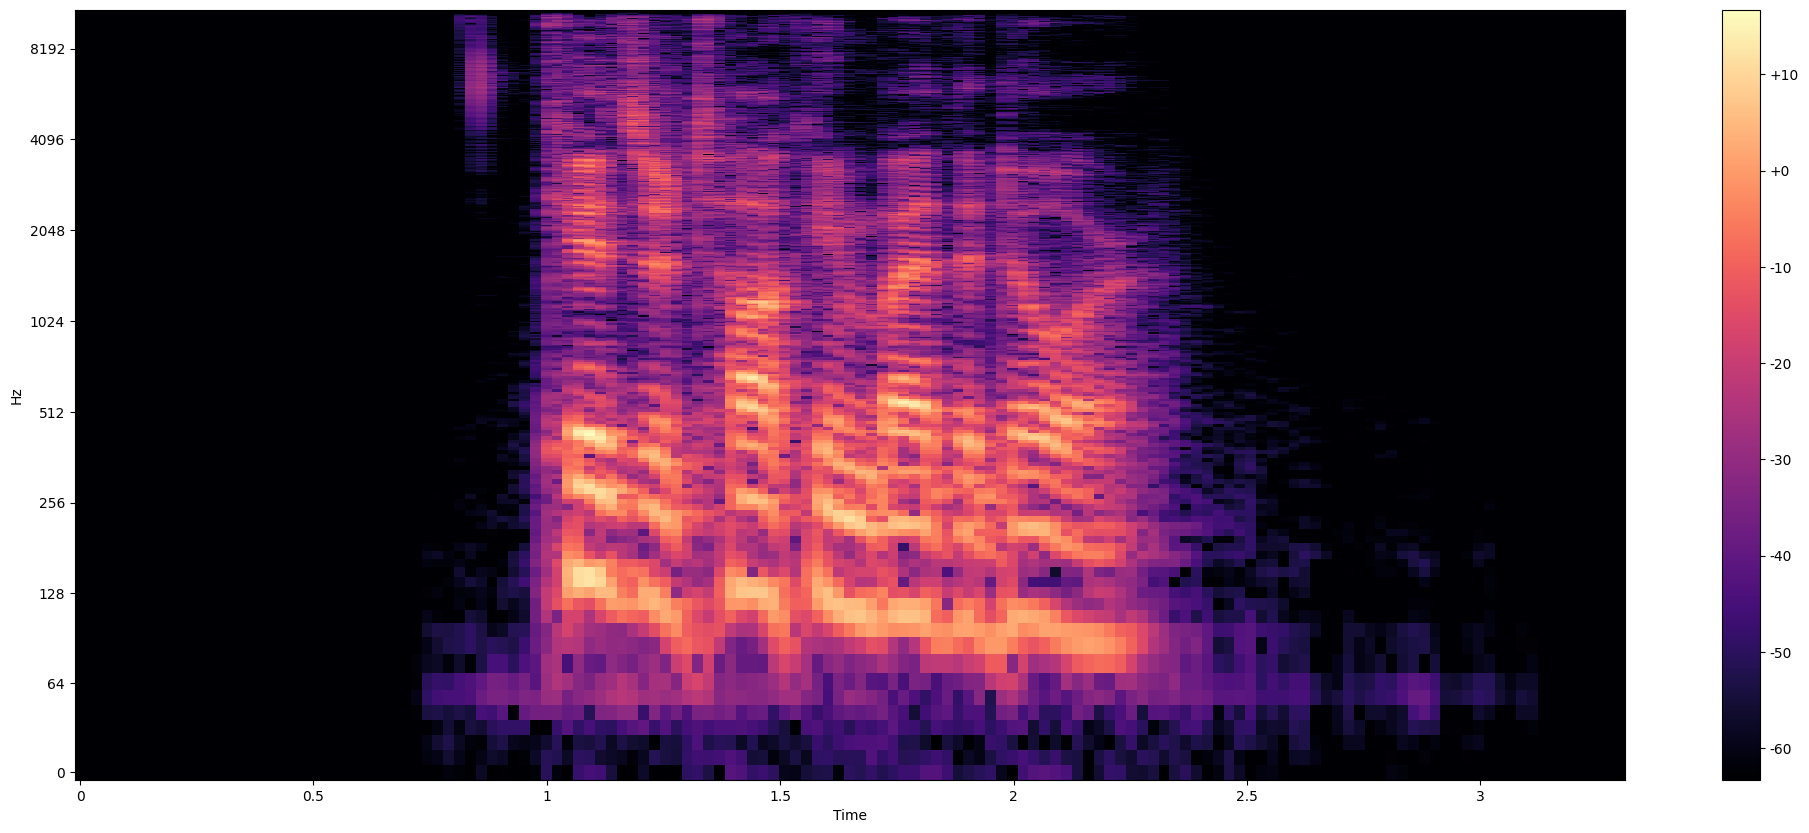

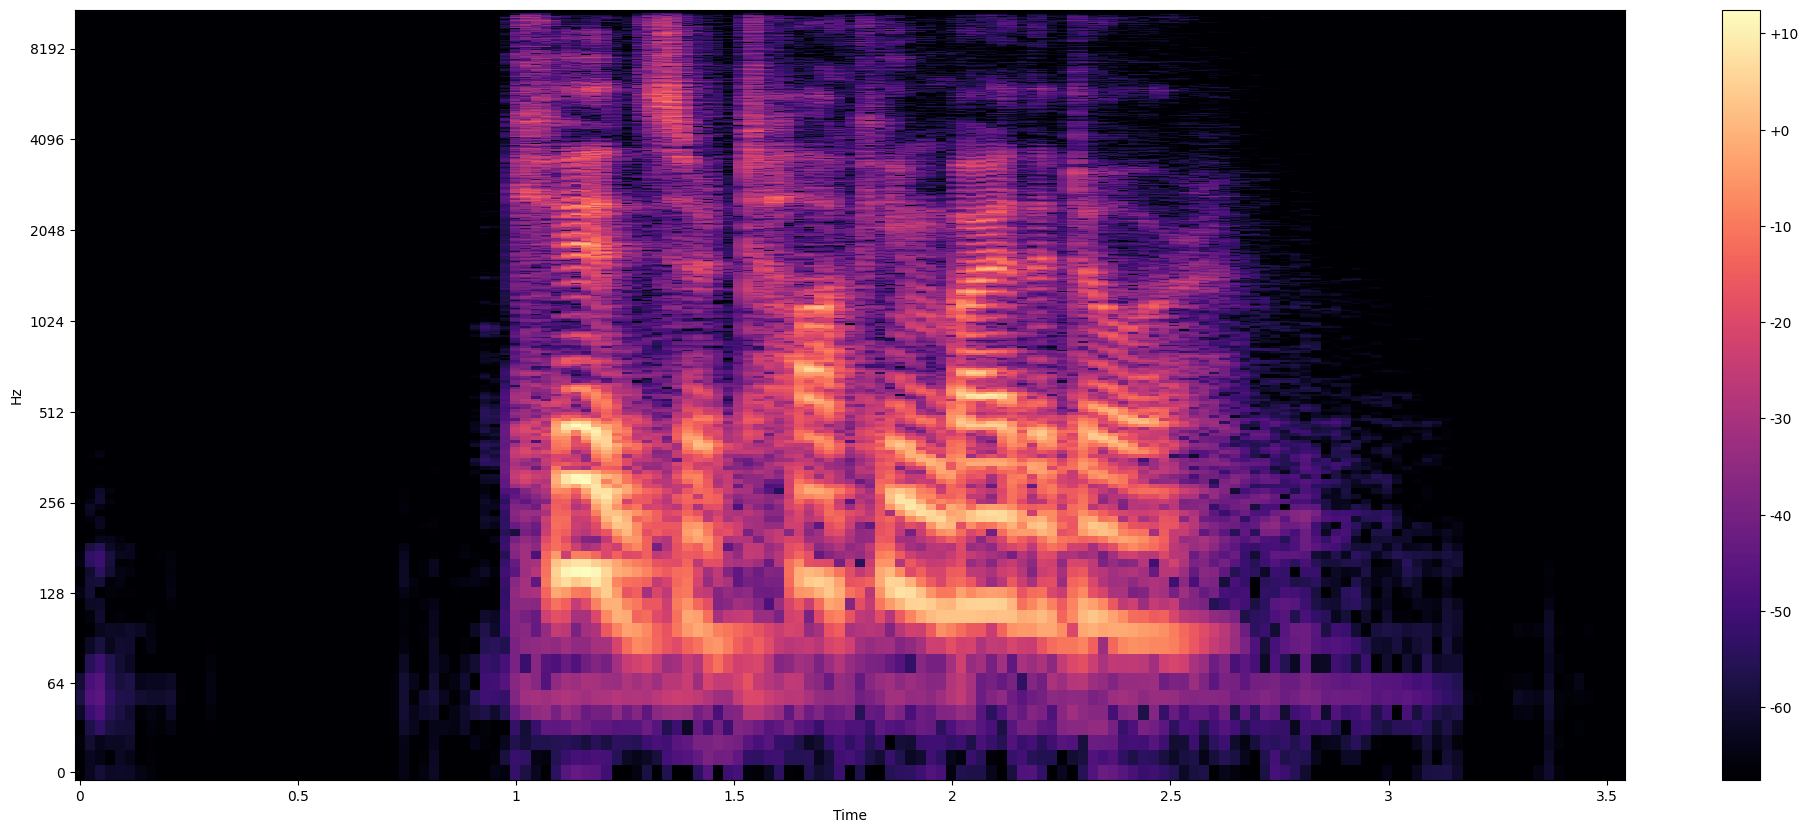

In [19]:
Y_scale_1_log = librosa.power_to_db(Y_scale_1)
Y_scale_2_log = librosa.power_to_db(Y_scale_2)

plot_spectrogram(Y_scale_1_log, sr, HOP_SIZE, y_axis="log")
plot_spectrogram(Y_scale_2_log, sr, HOP_SIZE, y_axis="log")

We are starting to see the magic in the implementation of spectrograms, but we still need a few more steps to obtain a representation that aligns better with how humans perceive sound. That **humanization** we mentioned earlier is achieved through Mel spectrograms.

Let's take a look at the Mel filters with 64 bands in raw form, without applying them to any signal, to understand how they look and how they are applied to the STFT.

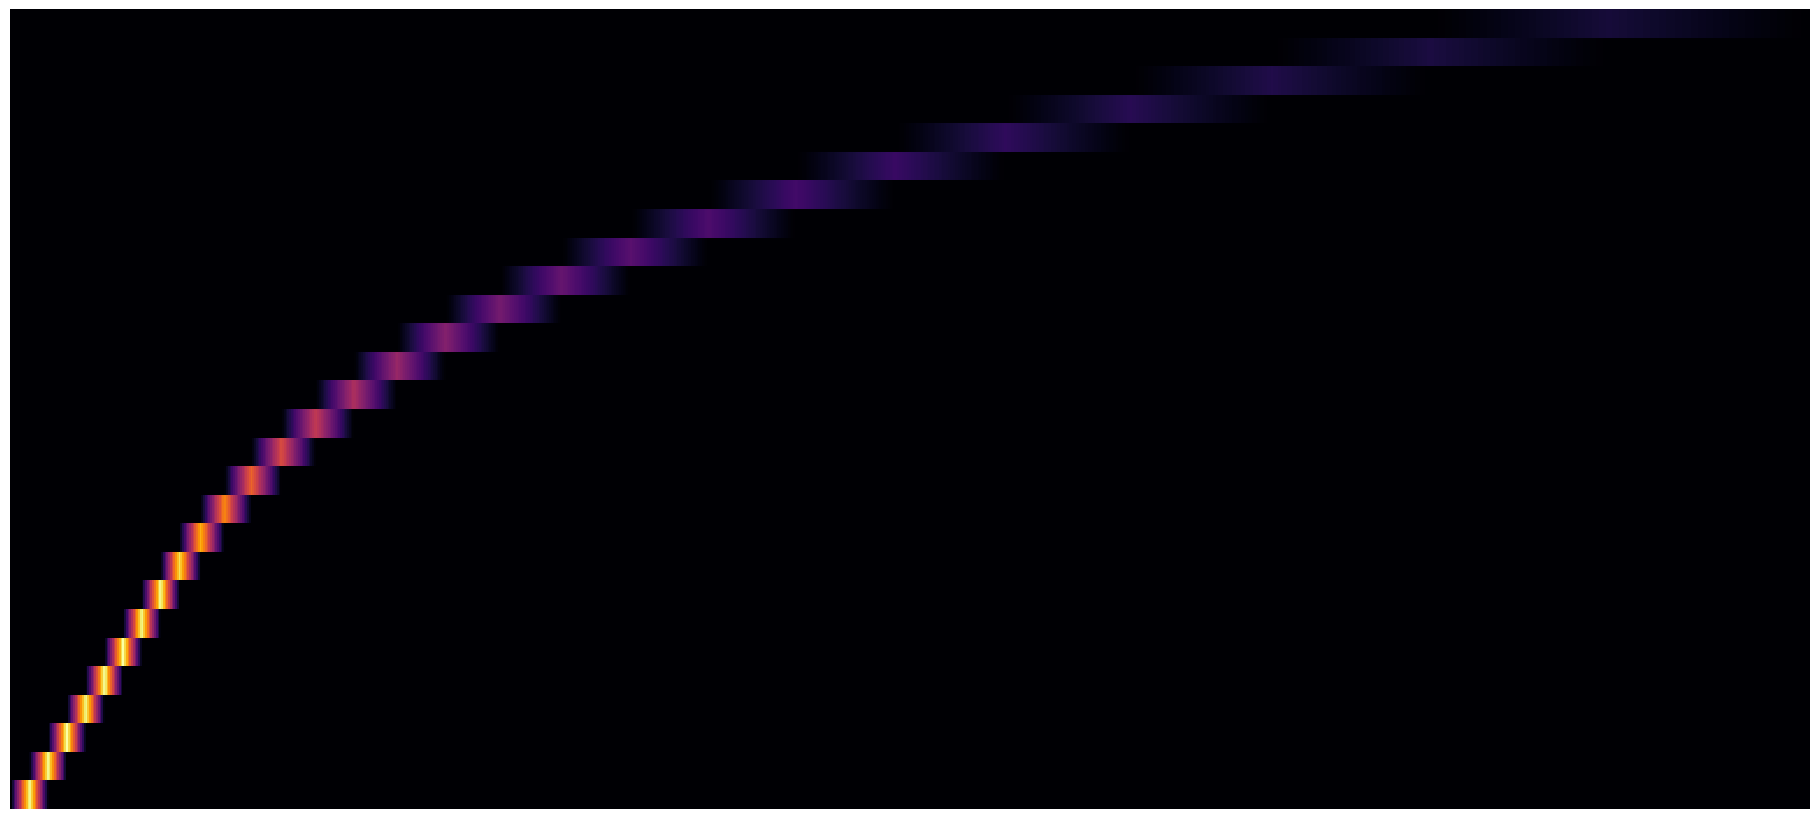

In [20]:
fig = plt.figure(figsize=(18, 8))
mel_filters_raw = librosa.filters.mel(sr=sr, n_fft=FRAME_SIZE, n_mels=28)
ax = fig.add_axes([0, 0, 1, 1])  # [izquierda, abajo, ancho, alto] del 0 al 1


librosa.display.specshow(mel_filters_raw,
                         sr=sr,
                         ax=ax,
                         cmap="inferno",
                         )
ax.axis("off")

plt.show()

In [21]:
mel_spectrogram_1 = librosa.feature.melspectrogram(y=signal, sr =sr, n_fft=FRAME_SIZE, hop_length=HOP_SIZE, n_mels=10)
mel_spectrogram_2 = librosa.feature.melspectrogram(y=signal_2, sr =sr, n_fft=FRAME_SIZE, hop_length=HOP_SIZE, n_mels=100)
log_mel_spectrogram_1 = librosa.power_to_db(mel_spectrogram_1)
log_mel_spectrogram_2 = librosa.power_to_db(mel_spectrogram_2)

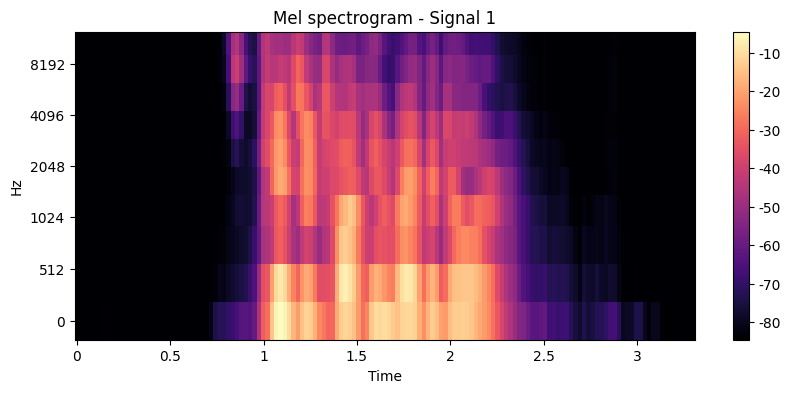

In [22]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(log_mel_spectrogram_1,
                         x_axis="time",
                         y_axis="mel",
                         sr=sr,)
plt.colorbar(format="%+2.f")
plt.title("Mel spectrogram - Signal 1")

plt.show()


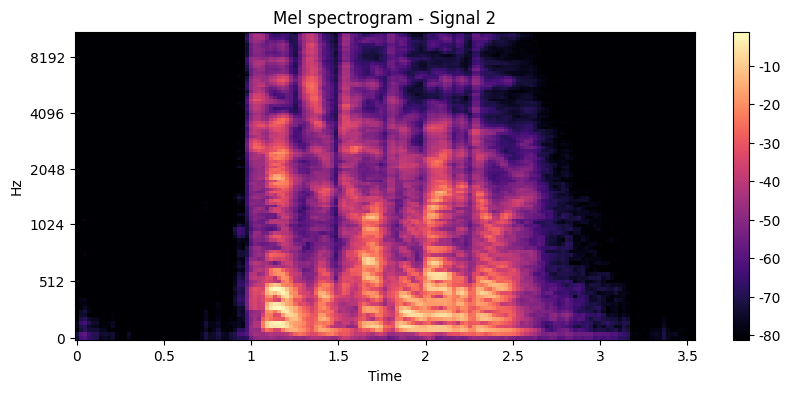

In [23]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_mel_spectrogram_2,
                         x_axis="time",
                         y_axis="mel",
                         sr=sr,)
plt.title("Mel spectrogram - Signal 2")
plt.colorbar(format="%+2.f")

plt.show()